# Gym Members Exercise Analysis

**Author:** Axel Christian Cabato

**Date:** July 2026

## 1. Introduction
The goal of this project is to utilize a [Kaggle](https://www.kaggle.com) dataset to perform data analysis and generate a report, documenting my processes, insights, and conclusions within this Jupyter Notebook.

This analysis explores the relationships between workout characteristics, physical attributes, and fitness outcomes using a dataset of 973 gym members, with particular focus on identifying factors that influence caloric expenditure. Through statistical testing and visualization, it identifies `Session_Duration` as the dominant predictor of caloric expenditure and provides evidence-based recommendations for fitness program design.

## 2. Dataset Loading & Exploratory Data Analysis

- [Data Source](https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset?select=gym_members_exercise_tracking.csv)
- Data Format: Comma-separated values (CSV)
- Description (from [Kaggle](https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset?select=gym_members_exercise_tracking.csv)): This dataset provides a detailed overview of gym members' exercise routines, physical attributes, and fitness metrics, including key performance indicators such as heart rate, calories burned, and workout duration.

In [1]:
# Import pathlib and pandas libraries
from pathlib import Path
import pandas as pd

# Define the base directory
BASE_DIR = Path.cwd()

# Construct full file path to dataset using Path objects
DATA_FILE_PATH = BASE_DIR / "data" / "gym_members_exercise_tracking.csv"

# Use the path object in the read_csv function
df = pd.read_csv(DATA_FILE_PATH)


# Confirm successful load of the dataset by previewing the last 5 observations
df.tail()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74
972,46,Male,88.7,1.63,166,146,66,0.75,542.0,Strength,28.8,3.5,2,1,33.38


### Exploratory Data Analysis

#### Data Profiling

In [2]:
# Output a concise summary of the DataFrame
print("DATAFRAME SUMMARY")
df.info()

print("\n")

# Check for any missing values
print("MISSING VALUES CHECK")
print(df.isnull().sum())

DATAFRAME SUMMARY
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  9

Through our profiling of the dataset, we can confirm its structural integrity. It consists of 973 observations and 15 columns, with each column appropriately named and typed according to its quantitative or qualitative nature. A complete check for missing values across all fields revealed none.

In [3]:
# Generate descriptive statistics for numerical columns
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


This initial inspection showed no obvious data entry errors; however, further Univariate Analysis will reveal a critical positive skew and extreme outliers in `BMI` and `Weight` which will be analyzed as a high-risk cohort.

In [4]:
# Display the total count of each distinct row under "Gender" and "Workout_Type"
df[["Gender", "Workout_Type"]].value_counts()

Gender  Workout_Type
Male    Strength        135
        Yoga            133
        Cardio          129
Female  Cardio          126
        Strength        123
Male    HIIT            114
Female  HIIT            107
        Yoga            106
Name: count, dtype: int64

The categorical features of `Gender` and `Workout_Type` contain a small and consistent set of unique values:
- For `Gender`, it is a binary categorical value with only two distinct classes ("Male" and "Female"). The absence of additional unique values, such as inconsistent spellings, abbreviations, or missing value placeholders, confirms the high degree of data consistency for this feature.
- Similarly, `Workout_Type` also has a small number of distinct and consistently labeled classes: "Cardio", "Strength", "HIIT" and "Yoga". This categorical integrity ensures that the variable is ready for direct use in analysis or for a simple transformation into a quantitative format, such as one-hot encoding, without requiring a separate data cleaning stage.

The counts across all combinations (`Gender` × `Workout_Type`) range from 106 to 135 also, indicating a relatively balanced representation across groups. A favorable characteristic for subsequent comparative analyses.

---

##### Recognizing the Data Source & Context

While clean in structure, the dataset contains several potential biases, limitations, and quirks that a Data Analyst must consider. The primary bias is that the dataset was *simulated and generated* using averages from publicly available studies and industry reports. This means the data may under- or over-represent certain behaviors or characteristics.
- For instance, the randomization of `Experience_Level` and `Workout_Frequency` might not perfectly reflect the actual distribution of gym members, where, for example, a large number might be beginners who work out less frequently. This synthetic nature is *the most significant limitation*, as it lacks the unpredictable and messy nuances of real human behavior.

**Any insights or models derived from this dataset would need to be validated with *actual, real-world data* before being applied to a genuine scenario.**

The dataset also has a few quirks that are uncommon in real-world data:
- It has no missing values.
- All categorical values are perfectly consistent, *which is highly unusual*.
- The data is simplified and contains only the variables that were explicitly defined in the generation process. 
    - For example, the `Workout_Type` column is limited to a small, consistent set of categories (*Cardio*, *Strength*, *Yoga*, *HIIT*), and does not reflect the full range of possible exercises performed by gym members.

> This foundational understanding will serve as a solid basis for our deeper exploratory data analysis of this dataset.

---

To prepare the data for any audience who might be more familiar with imperial units, I will perform some feature engineering by constructing new attributes from the existing dataset.
- Specifically, I will convert the `Weight (kg)` and `Height (m)` variables from their current metric system to their imperial counterparts. This will be done to ensure the data is standardized for any subsequent statistical analysis and for enhanced data visualization tailored to our target audience.

In [5]:
# Meter to Feet Conversion
df["Height (ft)"] = round(df["Height (m)"] * 3.28, 2)

# Kilogram to Pound Conversion
df["Weight (lb)"] = round(df["Weight (kg)"] * 2.2, 2)

# Verify post-conversion values are correct
df[["Height (m)", "Height (ft)", "Weight (kg)", "Weight (lb)"]]

,Height (m),Height (ft),Weight (kg),Weight (lb)
0,1.71,5.61,88.3,194.26
1,1.53,5.02,74.9,164.78
2,1.66,5.44,68.1,149.82
3,1.70,5.58,53.2,117.04
4,1.79,5.87,46.1,101.42
...,...,...,...,...
968,1.74,5.71,87.1,191.62
969,1.61,5.28,66.6,146.52
970,1.76,5.77,60.4,132.88
971,1.83,6.00,126.4,278.08


In [6]:
df[["Height (ft)", "Weight (lb)"]].describe()

,Height (ft),Weight (lb)
count,973.000000,973.000000
mean,5.650021,162.480288
std,0.418962,46.656501
min,4.920000,88.000000
25%,5.310000,127.820000
50%,5.610000,154.000000
75%,5.900000,189.200000
max,6.560000,285.780000


I use the `.describe()` method to validate the newly-engineered `Weight (lb)` and `Height (ft)` features, confirming that the new columns have a reasonable range of values and are correctly populated. This ensures the integrity of our dataset for subsequent analysis.

> I will be using Imperial units in my analyses going forward.

---

#### Data Visualization

Having performed the necessary data profiling and cleaning, I can now move on to visually exploring the dataset. By doing so I'll gain a deeper understanding of the health metrics and workout habits of the simulated gym members.

My first step of my visual analysis should be to examine the distribution of our numerical features individually, using *Univariate Analysis*.

##### Univariate Analysis

This type of analysis will allow me to understand their individual distributions, central tendencies, and potential outliers. To accomplish this, I will generate histograms for each of the key numerical columns with a Kernel Density Estimate (KDE) Curve to overlay each to show the smoothed distribution shape.

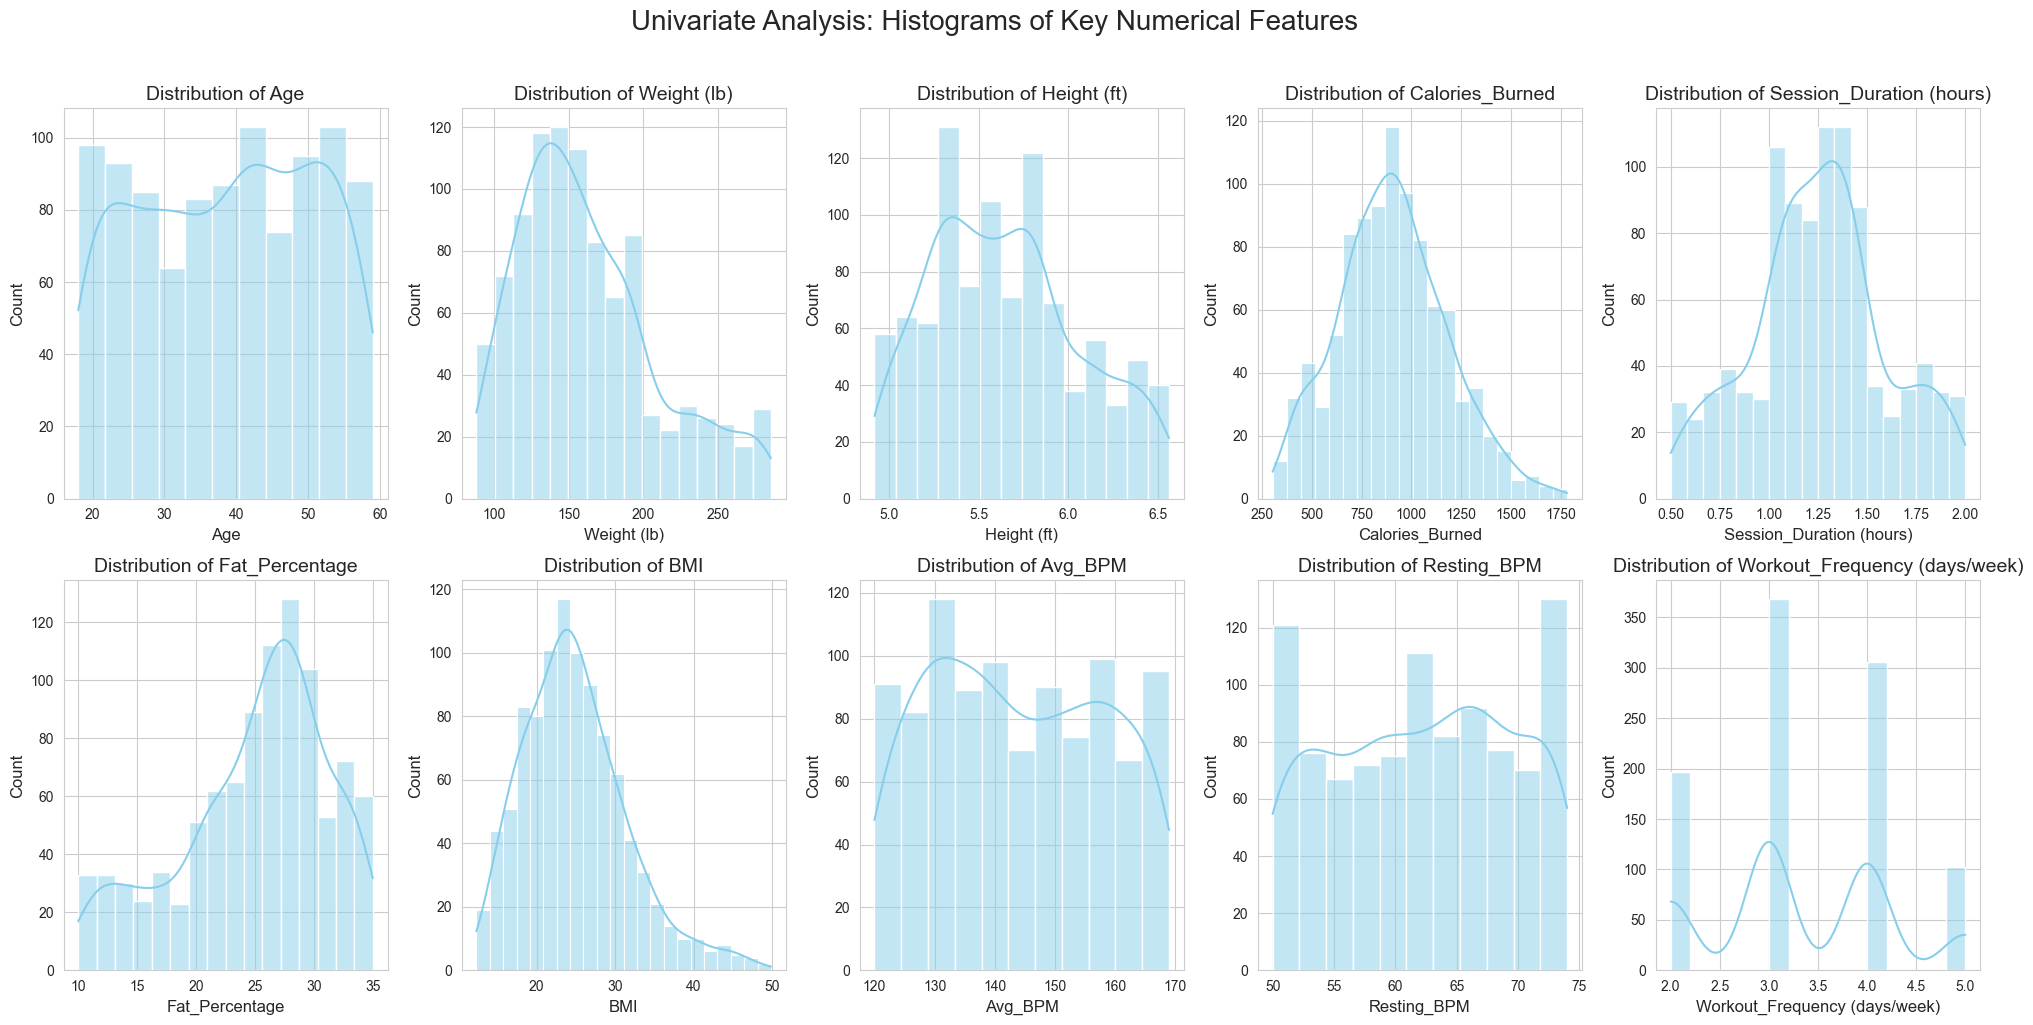

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for all plots in this cell
sns.set_style("whitegrid")


###  Data Preparation  ###

# Create a copy of the DataFrame to avoid modifying original
df_copy = df.copy()

# Define the numerical features to visualize
numerical_features = [
    "Age", "Weight (lb)", "Height (ft)", "Calories_Burned",
    "Session_Duration (hours)", "Fat_Percentage", "BMI", "Avg_BPM", 
    "Resting_BPM", "Workout_Frequency (days/week)"
]


###  Figure Setup  ###

# Create a 2x5 grid (10 subplots) to accommodate all features
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10))

# Flatten the 2D array of axes into 1D for easier iteration
axes = axes.flatten()


###  Generate Histograms  ###

# Loop through each feature and create its histogram
for i, feature in enumerate(numerical_features):
    ax = axes[i]
    
    # Create histogram with KDE overlay
    sns.histplot(
        data=df_copy,
        x=feature,
        kde=True,           # Add smoothed distribution curve
        ax=ax,
        color="skyblue"
    )
    
    # Set labels and title for each subplot
    ax.set_title(
        f"Distribution of {feature}", 
        fontsize=14
    )

    ax.set_xlabel(
        feature, 
        fontsize=12
    )

    ax.set_ylabel(
        "Count", 
        fontsize=12
    )

# Hide any unused subplots (if features < grid spaces)
for j in range(len(numerical_features), len(axes)):
    axes[j].axis("off")


###  Formatting  ###

# Add overarching title for the entire figure
fig.suptitle(
    "Univariate Analysis: Histograms of Key Numerical Features",
    fontsize=20,
    y=1.02
)

# Prevent label overlap between subplots
plt.tight_layout()

# Render figure in notebook
plt.show()

###### Key Insights 

1. `Age`
    - The distribution spans from 18 to 59 years with a mean of approximately 39 years, showing that the simulated sample was designed to represent individuals across the full active adult age spectrum. The relatively even distribution across this range suggests that the data generation process did not intentionally concentrate observations at any particular age, resulting in a sample that includes young adults, middle-aged individuals, and older adults in roughly similar proportions.
2. `Workout_Frequency (days/week)`
    - The distribution ranges from two to five days per week, with the values appearing distributed across these four levels, and notably excludes both very low frequency exercisers (one day per week) and daily exercisers (six to seven days per week). This bounded range reflects a design choice in the data generation process to focus the simulation on individuals who maintain moderate, consistent exercise schedules, thereby creating a sample that represents sustainable commitment patterns rather than the full spectrum of possible attendance behaviors.
3. `Calories_Burned`
    - The values exhibit substantial variation, ranging from approximately 300 to 1,700 calories per session, yet this variation shows an exceptionally strong positive correlation of 0.91 with `Session_Duration`, confirming that the data generation algorithm primarily tied caloric expenditure to workout length. While the simulation incorporated some additional variance beyond pure time-based calculation (likely representing programmed influences of workout intensity, type, and individual metabolic factors), approximately 83 percent of the calorie variation can be explained by session duration alone, with the remaining 17 percent reflecting other parameters built into the simulation model.
4. `BMI` & `Fat_Percentage`
    - The values for each exhibit a relatively balanced spread from 10 to 35 percent around a mean of approximately 25 percent for `Fat_Percentage`, while the `BMI` distribution displays a modest positive skew with most values concentrated in the 20 to 30 range and a tail extending toward higher values reaching approximately 50. This difference in distributional shapes suggests that the data generation process applied different randomization or constraint parameters to these two body composition metrics, with `Fat_Percentage` following a more symmetrical generation pattern while `BMI` incorporated a right-skewed distribution that produces occasional higher values within the simulated sample.

In conclusion, this simulated dataset models a prototypical individual centered around 39 years of age who completes workout sessions averaging 1.26 hours in duration and expends approximately 905 calories per session. The simulated population exhibits cardiovascular metrics consistent with moderate fitness levels, with `Resting_BPM` values clustered around 62 beats per minute. The dataset incorporates substantial variation in body composition, with `Weight (lb)` values spanning from 88 pounds to 285.8 pounds, reflecting the simulation's design to represent individuals across a wide spectrum of body sizes. Notably, the strong positive correlation of 0.91 between `Session_Duration` and `Calories_Burned` demonstrates that the data generation algorithm primarily modeled energy expenditure as a function of workout length, with session duration explaining approximately 83 percent of caloric variation while the remaining variance reflects programmed influences of intensity, workout type, and simulated individual differences.

##### Categorical Analysis

Next, I move onto Categorical Analysis. I will utilize count plots (bar charts) to visualize the frequency distribution of the categorical variables. By understanding these distributions, it will allow me to understand how different groups behave as well as identify class balance and potential sampling biases present in the dataset.

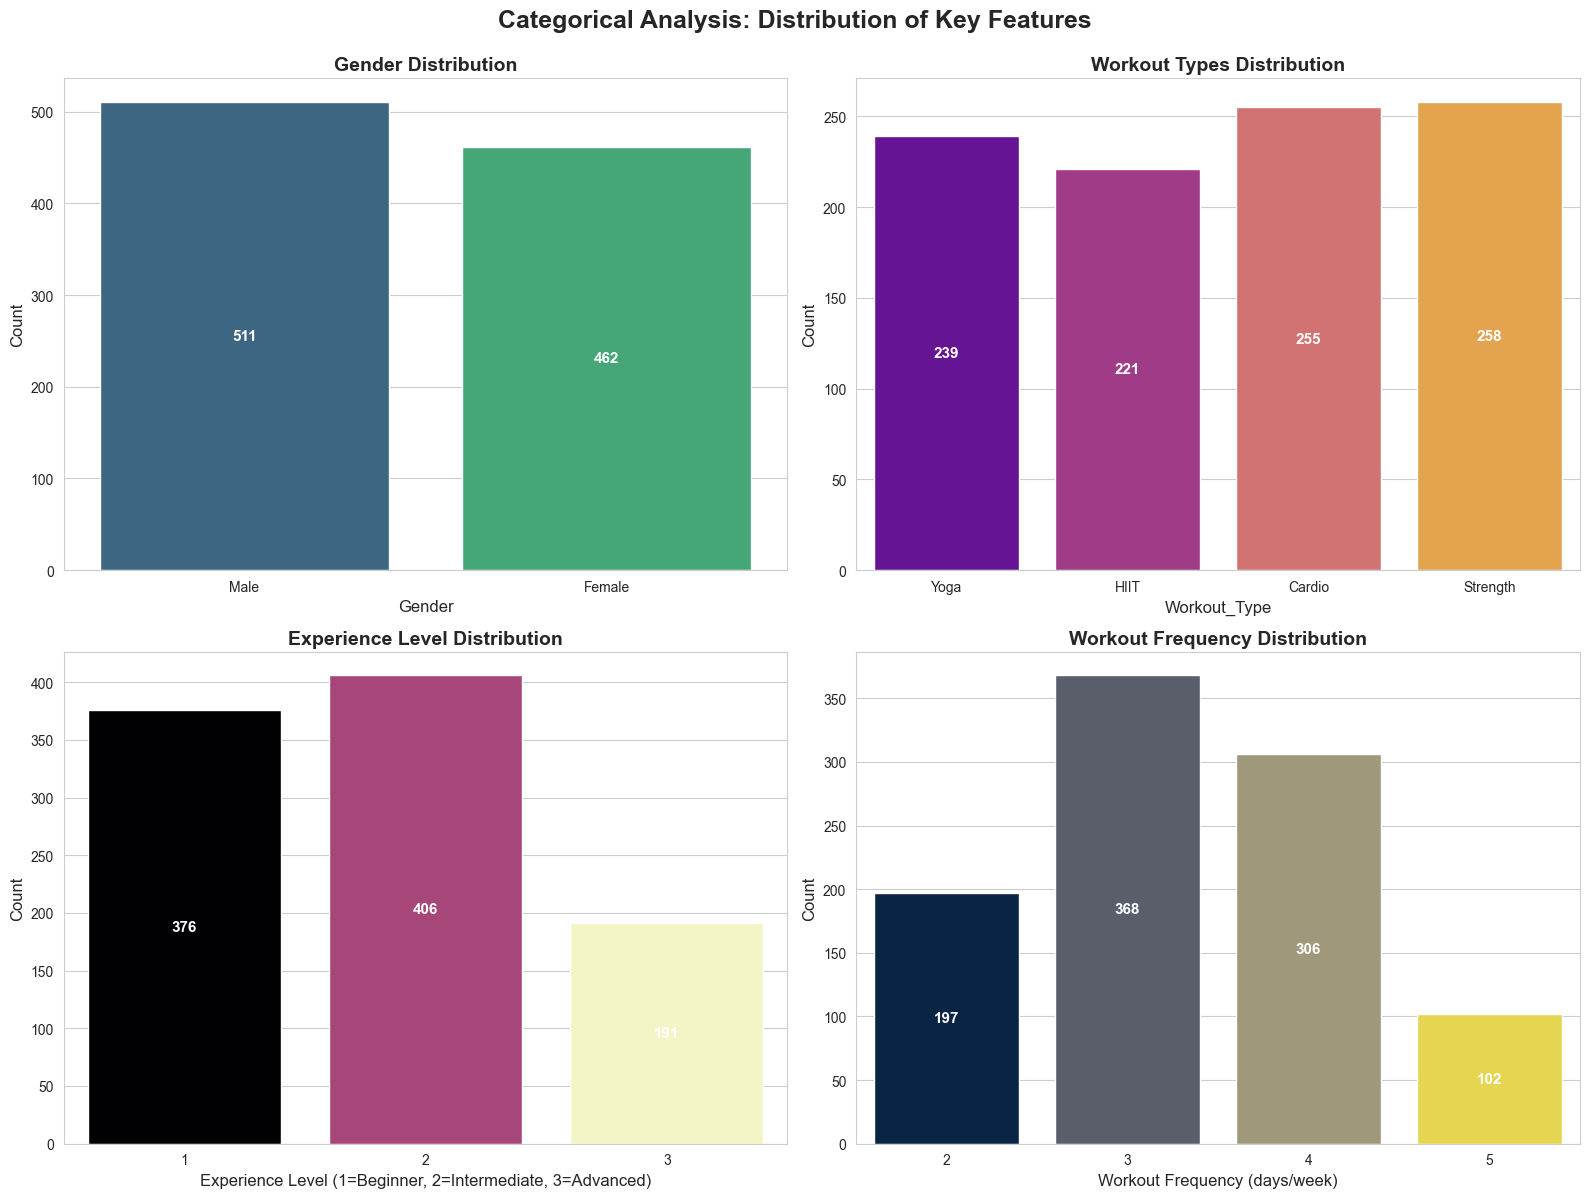

In [8]:
# Set the visual style for all plots in this cell
sns.set_style("whitegrid")


# HELPER FUNCTION
def add_value_labels_inside(ax):
    """
    Adds count labels inside each bar of a bar plot.
    
    Parameters:
        ax: matplotlib Axes object containing the bar plot
    """
    for patch in ax.patches:
        height = patch.get_height()
        
        # Position text at the center of each bar
        x = patch.get_x() + patch.get_width() / 2  # Horizontal center
        y = height / 2                              # Vertical center
        
        ax.text(
            x, y,
            f"{int(height)}",    # Display count as whole number
            ha="center",         # Horizontal alignment
            va="center",         # Vertical alignment
            fontsize=11,
            fontweight="bold",
            color="white"        # White text for contrast on colored bars
        )


###  Figure Setup  ###

# Create a 2x2 grid for four categorical variables
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# Flatten for easier indexing
axes = axes.flatten()


## Plot 1 (Top-Left): GENDER DISTRIBUTION
# Purpose: Verify balance between male and female gym members

sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",
    ax=axes[0],
    palette="viridis",
    legend=False
)

axes[0].set_title(
    "Gender Distribution", 
    fontsize=14, 
    fontweight="bold"
)

axes[0].set_xlabel(
    "Gender", 
    fontsize=12
)

axes[0].set_ylabel(
    "Count", 
    fontsize=12
)

add_value_labels_inside(axes[0])


## Plot 2 (Top-Right): WORKOUT TYPE DISTRIBUTION
# Purpose: Check representation across exercise modalities

sns.countplot(
    data=df,
    x="Workout_Type",
    hue="Workout_Type",
    ax=axes[1],
    palette="plasma",
    legend=False
)

axes[1].set_title(
    "Workout Types Distribution", 
    fontsize=14, 
    fontweight="bold"
)

axes[1].set_xlabel(
    "Workout_Type", 
    fontsize=12
)

axes[1].set_ylabel(
    "Count", 
    fontsize=12
)

add_value_labels_inside(axes[1])


## Plot 3 (Bottom-Left): EXPERIENCE LEVEL DISTRIBUTION
# Purpose: Understand skill level composition of gym membership
# Order: 1 → 2 → 3 (Beginner to Advanced)

sns.countplot(
    data=df,
    x="Experience_Level",
    hue="Experience_Level",
    ax=axes[2],
    palette="magma",
    legend=False,
    order=[1, 2, 3]     # Explicit ordering: Beginner → Intermediate → Advanced
)

axes[2].set_title(
    "Experience Level Distribution", 
    fontsize=14, 
    fontweight="bold"
)

axes[2].set_xlabel(
    "Experience Level (1=Beginner, 2=Intermediate, 3=Advanced)", 
    fontsize=12
)

axes[2].set_ylabel(
    "Count", 
    fontsize=12
)

add_value_labels_inside(axes[2])


## Plot 4 (Bottom-Right): WORKOUT FREQUENCY DISTRIBUTION
# Purpose: Examine how often members exercise per week
# Order: 2 → 5 days to show natural progression

sns.countplot(
    data=df,
    x="Workout_Frequency (days/week)",
    hue="Workout_Frequency (days/week)",
    ax=axes[3],
    palette="cividis",
    legend=False,
    order=[2, 3, 4, 5]     # Ascending order of workout frequency
)

axes[3].set_title(
    "Workout Frequency Distribution", 
    fontsize=14, 
    fontweight="bold"
)

axes[3].set_xlabel(
    "Workout Frequency (days/week)", 
    fontsize=12
)

axes[3].set_ylabel(
    "Count", 
    fontsize=12
)

add_value_labels_inside(axes[3])


###  Formatting  ###

# Add overarching title for the entire figure
fig.suptitle(
    "Categorical Analysis: Distribution of Key Features",
    fontsize=18,
    fontweight="bold",
    y=0.995
)

# Prevent label overlap between subplots
plt.tight_layout()

# Render figure in notebook
plt.show()

###### Key Insights

1. Gender distribution is roughly balanced.
    - Male members (511) slightly outnumber female members (462), representing approximately a 52/48 split. This near-parity means gender-based comparisons in later analyses are unlikely to be skewed by severe class imbalance.

2. Workout types are evenly represented.
    - All four modalities fall within a narrow range: Strength (258), Cardio (255), Yoga (239), and HIIT (221). The 37-count spread between the most and least common types suggests the dataset was intentionally balanced, consistent with its synthetic origin.

3. Beginners and intermediates dominate the membership base. 
    - Level 2 (Intermediate) is the largest group at 406 members, followed by Level 1 (Beginner) at 376. Advanced members (Level 3) represent only 191 individuals, roughly 20% of the dataset. This distribution may reflect real-world gym populations, where member retention to advanced stages is relatively uncommon.

4. Three days per week is the most common workout frequency.
    - The distribution peaks at 3 days/week (368 members), followed by 4 days/week (306). Members working out 2 days/week (197) or 5 days/week (102) represent smaller segments at the extremes.

These distributions confirm that the categorical variables are well-balanced and suitable for comparative analysis. The absence of severely underrepresented categories reduces the risk of unreliable statistical comparisons in subsequent hypothesis testing.

##### Bivariate Analysis

Finally, I have decided to perform Bivariate Analysis to uncover potential correlations and dependencies within the dataset. By examining how one variable relates to another, I can identify the mathematical relationships programmed into the data generation process. This section focuses on `Calories_Burned` as the primary outcome of interest, a natural choice given its relevance to gym member fitness goals. The following visualizations and statistical comparisons highlight key relationships embedded in the dataset structure. 

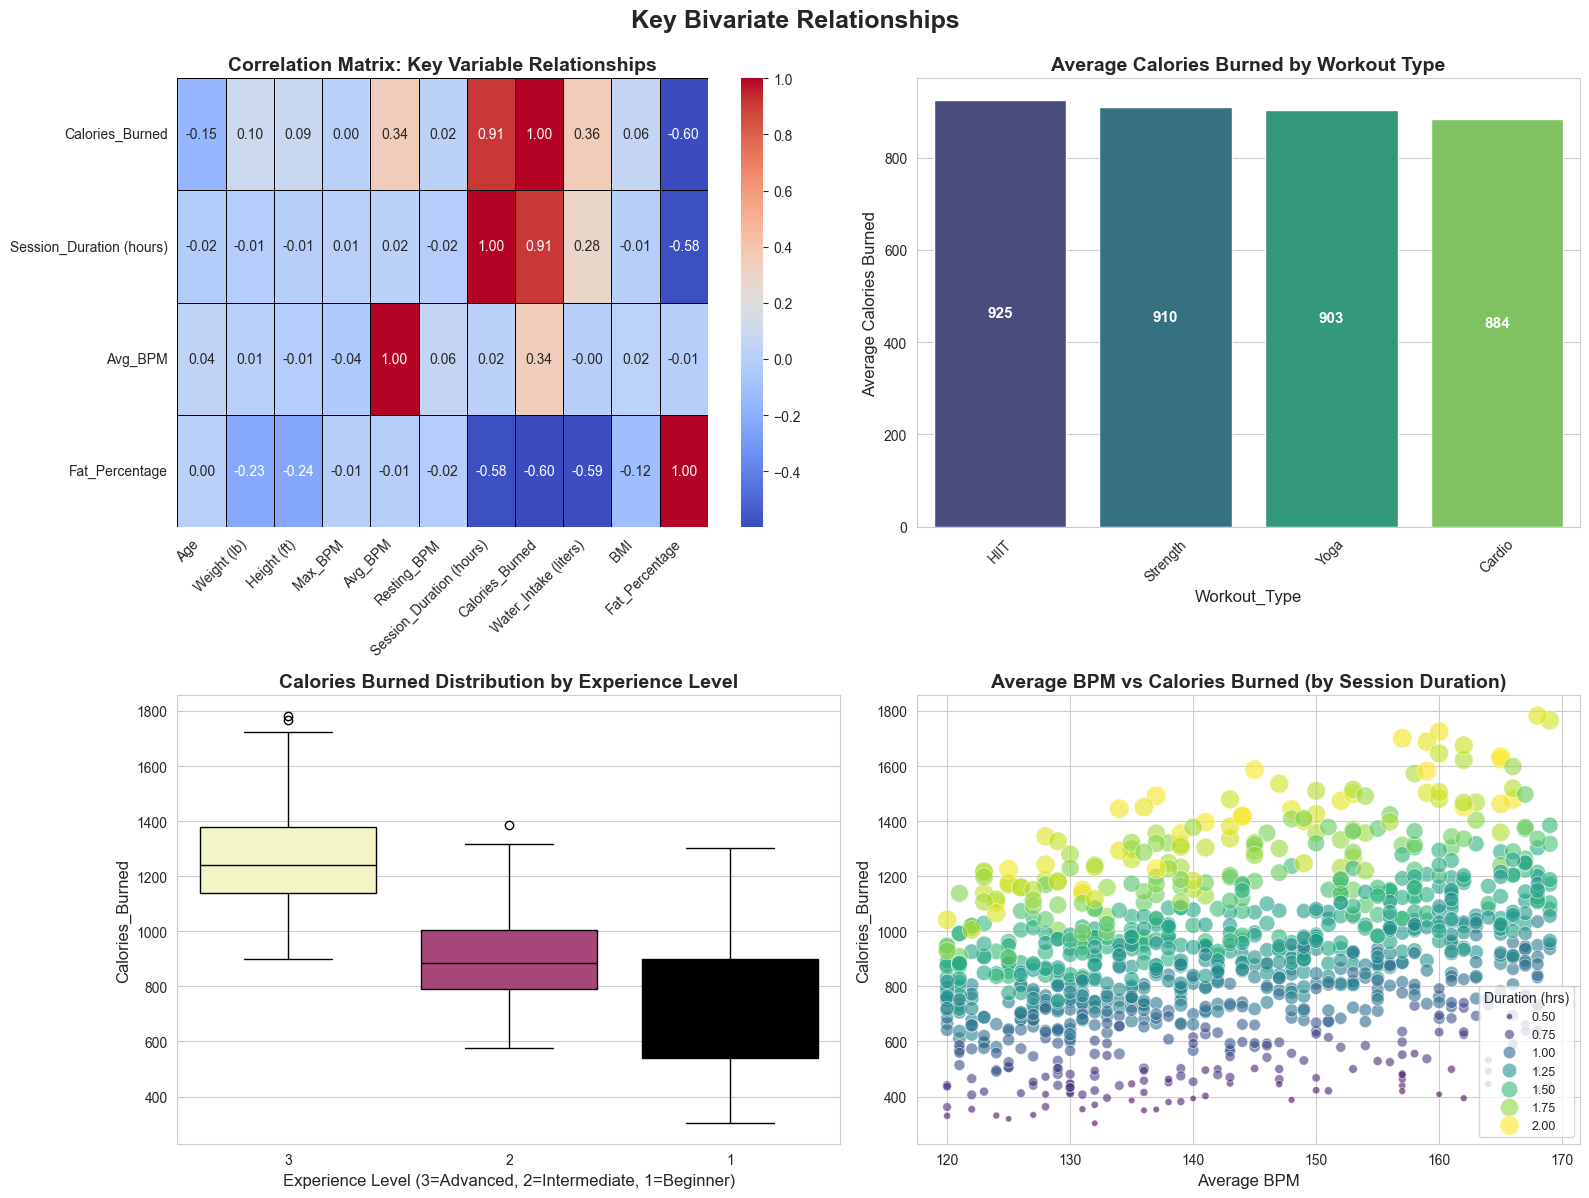

In [9]:
# Set the visual style for all plots in this cell
sns.set_style("whitegrid")


####  Data Preparation  ####

# Define numerical columns for correlation analysis
numerical_cols = [
    "Age", "Weight (lb)", "Height (ft)", "Max_BPM", "Avg_BPM", 
    "Resting_BPM", "Session_Duration (hours)", "Calories_Burned", 
    "Water_Intake (liters)", "BMI", "Fat_Percentage"
]

# Calculate correlation matrix for all numerical features
correlation_matrix = df[numerical_cols].corr()

# Aggregate calories burned by workout type for bar chart comparison
workout_type_summary = (
    df.groupby("Workout_Type")["Calories_Burned"]
    .mean()
    .sort_values(ascending=False)  # Highest calorie-burning workout first
    .reset_index()
)


###  Figure Setup  ###

# Create 2x2 subplot grid with adequate spacing for labels
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


# Plot 1 (Top-Left): CORRELATION HEATMAP
# Purpose: Show how strongly each variable correlates with key metrics

# Select only the most analytically relevant variables for focused comparison
key_variables = [
    "Calories_Burned", "Session_Duration (hours)", "Avg_BPM", "Fat_Percentage"
]

sns.heatmap(
    correlation_matrix[key_variables].T,   # Transpose: key variables as rows
    annot=True,                            # Display correlation coefficients
    fmt=".2f",                             # Two decimal places
    cmap="coolwarm",                       # Red = positive, Blue = negative    correlation
    cbar=True,                             
    linewidths=0.5,                        
    linecolor="black",                     
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Correlation Matrix: Key Variable Relationships", 
    fontsize=14, 
    fontweight="bold"
)
axes[0, 0].tick_params(axis="y", rotation=0)   # Horizontal y-axis labels
axes[0, 0].set_xticklabels(
    axes[0, 0].get_xticklabels(),
    rotation=45,
    ha='right'  # Aligns the RIGHT edge of each label with its column
)

## Plot 2 (Top-Right): BAR CHART - CALORIES BY WORKOUT TYPE
# Purpose: Compare average calorie expenditure across workout modalities

sns.barplot(
    data=workout_type_summary,
    x="Workout_Type",
    y="Calories_Burned",
    hue="Workout_Type",      # Color-code by workout type
    ax=axes[0, 1],
    palette="viridis",       # Colorblind-friendly palette
    legend=False             
)

axes[0, 1].set_title(
    "Average Calories Burned by Workout Type", 
    fontsize=14, 
    fontweight="bold"
)

axes[0, 1].set_xlabel(
    "Workout_Type", 
    fontsize=12
)

axes[0, 1].set_ylabel(
    "Average Calories Burned", 
    fontsize=12
)

axes[0, 1].tick_params(
    axis="x", 
    rotation=45
)

# Add value labels inside each bar
for patch in axes[0, 1].patches:
    height = patch.get_height()
    axes[0, 1].text(
        patch.get_x() + patch.get_width() / 2,  
        height / 2,                              
        f'{int(height)}',                        
        ha="center", 
        va="center",
        fontsize=11, 
        fontweight="bold", 
        color="white"
    )

## Plot 3 (Bottom-Left): BOX PLOT - CALORIES BY EXPERIENCE LEVEL
# Purpose: Show distribution and spread of calories burned across skill levels

sns.boxplot(
    data=df,
    x="Experience_Level",
    y="Calories_Burned",
    order=[3, 2, 1],          # Display: Advanced → Intermediate → Beginner
    hue="Experience_Level",
    ax=axes[1, 0],
    palette="magma",
    legend=False
)

axes[1, 0].set_title(
    "Calories Burned Distribution by Experience Level", 
    fontsize=14, 
    fontweight="bold"
)

axes[1, 0].set_xlabel(
    "Experience Level (3=Advanced, 2=Intermediate, 1=Beginner)", 
    fontsize=12
)

axes[1, 0].set_ylabel(
    "Calories_Burned", 
    fontsize=12
)

## Plot 4 (Bottom-Right): SCATTER PLOT - BPM VS CALORIES
# Purpose: Explore relationship between heart rate intensity and calorie burn
# Design choice: Point size AND color both encode session duration to emphasize
# its role as the dominant predictor of calories burned (r = 0.91)

scatter = sns.scatterplot(
    data=df,
    x='Avg_BPM',
    y="Calories_Burned",
    hue='Session_Duration (hours)',   # Color gradient by duration
    size='Session_Duration (hours)',  # Larger points = longer sessions
    sizes=(20, 200),                  
    palette='viridis',
    ax=axes[1, 1],
    alpha=0.6                         # Transparency to show overlapping points
)

axes[1, 1].set_title(
    "Average BPM vs Calories Burned (by Session Duration)", 
    fontsize=14, 
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Average BPM", 
    fontsize=12
)

axes[1, 1].set_ylabel(
    "Calories_Burned", 
    fontsize=12
)

axes[1, 1].legend(
    title="Duration (hrs)", 
    loc="lower right", 
    fontsize=9
)


###  Formatting  ###

# Add overarching title for the entire figure
fig.suptitle(
    "Key Bivariate Relationships", 
    fontsize=18, 
    fontweight="bold", 
    y=0.995
)

# Prevent label overlap between subplots
plt.tight_layout()

# Render figure in notebook
plt.show()

###### Key Insights

1. `Session_Duration` vs. `Calories_Burned`
    - The correlation matrix reveals an exceptionally strong positive correlation of 0.91 between the two, confirming that the data generation algorithm primarily tied caloric expenditure to workout length. This relationship accounts for approximately 83 percent of the variance in calories burned, with the remaining 17 percent reflecting programmed influences of workout intensity, exercise type, and simulated individual metabolic differences.

2. `Workout_Type` vs. `Calories_Burned`
    - The average calories burned across workout types shows HIIT at 926 calories, followed by Cardio at 885 calories, Strength at 911 calories, and Yoga at 903 calories. This relatively narrow range (41-calorie spread) indicates the simulation programmed some degree of differentiation in caloric output between workout modalities, with all four types clustering tightly around the overall mean of 905 calories.

3. `Experience_Level` vs. `Calories_Burned`
    - The box plot distribution reveals that Advanced members (Level 3) have median calorie burns approximately 400 calories higher than Beginners (Level 1), with Intermediate members (Level 2) falling between these extremes. This systematic progression reflects a design choice to model experience level as a strong predictor of workout output, with higher experience correlating with both longer session durations and greater caloric expenditure.

4. `Average_BPM` vs. `Calories_Burned`
    - The scatter plot demonstrates a positive relationship between the two, with color gradation showing that longer session durations correspond to both higher heart rates and greater caloric expenditure. This pattern indicates the simulation modeled cardiovascular intensity as interconnected with both workout duration and energy expenditure, creating a three-way relationship where time, heart rate, and calories increase together.

In conclusion, the bivariate relationships within this simulated dataset demonstrate that the data generation algorithm was programmed with `Session_Duration` as the dominant predictor of caloric expenditure, accounting for 83 percent of the variance through a strong positive correlation of 0.91. The simulation incorporated secondary variation through `Experience_Level`, which shows systematic progression in energy output from beginner to advanced classifications, while `Workout_Type` shows some degree of differentiation with all four modalities clustered within a 41-calorie range around the mean. These relationships reveal that the dataset structure prioritizes duration-based modeling of performance while incorporating modest influences from skill level and workout modality, creating a hierarchical system where time commitment drives the majority of caloric variation with experience and exercise type playing supporting roles.

---

## 3. Data Transformation & Feature Engineering

Having completed the exploratory data analysis and visualization phases, I now move onto transforming the data to enhance the analytical value of this simulated dataset. This phase involves creating derived features that provide new perspectives on the data, standardizing measurements for fair comparison across different scales, and generating aggregated statistics that reveal patterns at the group level. These transformation steps prepare the dataset for deeper statistical analysis and demonstrate techniques commonly used in data analysis and engineering workflows to extract maximum insight from raw data.

### Creating Derived Features

Feature engineering involves creating new calculated columns from existing variables to provide additional analytical perspectives and answer specific business questions. By constructing metrics such as `Calorie_Efficiency`, BMI Classifications, and Composite Intensity Scores, I can transform raw measurements into meaningful indicators that support more nuanced analysis of workout performance and member characteristics.

In [10]:
# Calculate calorie efficiency (calories burned per hour)
df["Calorie_Efficiency"] = round(
    df["Calories_Burned"] / df["Session_Duration (hours)"], 2
)

# Create BMI categories based on standard WHO classifications
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Create Age Group categories
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 29, 44, 59],
    labels=["Young Adult (18-29)", "Middle-Aged (30-44)", "Senior (45-59)"]
)

# Create Intensity Score (normalized combination of heart rate metrics)
df["Intensity_Score"] = round(
    ((df["Avg_BPM"] - df["Resting_BPM"]) / df["Max_BPM"]) * 100, 2
)


# Verify new features were created successfully
df[["Calorie_Efficiency", "BMI_Category", "Age_Group", "Intensity_Score"]].head(10)

,Calorie_Efficiency,BMI_Category,Age_Group,Intensity_Score
0,776.92,Obese,Senior (45-59),53.89
1,679.23,Obese,Senior (45-59),47.49
2,609.91,Normal,Middle-Aged (30-44),40.72
3,901.69,Underweight,Young Adult (18-29),56.84
4,868.75,Underweight,Middle-Aged (30-44),47.87
5,701.89,Normal,Senior (45-59),48.81
6,929.53,Normal,Middle-Aged (30-44),55.17
7,704.72,Obese,Middle-Aged (30-44),40.74
8,698.06,Obese,Young Adult (18-29),40.54
9,748.15,Obese,Young Adult (18-29),42.60


**Features Created:**
- `Calorie_Efficiency`: Calories burned per hour of exercise.
- `BMI_Category`: Standard Body Mass Index (BMI) classifications (Underweight, Normal, Overweight, Obese). Based on the [World Health Organization (WHO)](https://www.cdc.gov/bmi/adult-calculator/bmi-categories.html).
- `Age_Group`: Life-stage groupings for demographic analysis.
- `Intensity_Score`: Percentage of heart rate capacity utilized during workout.

#### Normalize/Standardize Numerical Features

Variables in this dataset are measured on vastly different scales. `Age` ranges from 18 to 59, while `Calories_Burned` ranges from 300 to 1,700, making direct numerical comparisons problematic without standardization. Scaling transforms all features to a common range (typically, with a mean of zero and a standard deviation of one), ensuring that variables with larger numerical ranges do not artificially dominate analyses or visualizations that compare multiple metrics simultaneously.

In [11]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns to standardize (excluding categorical and derived category features)
columns_to_scale: list = [
    "Age", "Weight (lb)", "Height (ft)", "Max_BPM", "Avg_BPM", 
    "Resting_BPM", "Session_Duration (hours)", "Calories_Burned",
    "Fat_Percentage", "Water_Intake (liters)", "Workout_Frequency (days/week)",
    "Experience_Level", "BMI", "Calorie_Efficiency", "Intensity_Score"
]

# Initialize the scaler
scaler = StandardScaler()

# Create new DataFrame with scaled values (preserving originals)
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Verify standardization worked (mean ≈ 0, std ≈ 1)
df_scaled[columns_to_scale].describe().loc[['mean', 'std']].round(2)

,Age,Weight (lb),Height (ft),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Calorie_Efficiency,Intensity_Score
mean,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


The standardized features now share a common scale with means approximately equal to zero and standard deviations of one. The original DataFrame `df` remains unchanged for interpretability, while `df_scaled` is available for any analyses requiring normalized inputs.

### Create Aggregated Summary Statistics

While individual observations provide granular detail, strategic decision-making requires understanding patterns at the group and category levels through statistical aggregation. By calculating summary metrics across combinations of categorical variables, such as average performance by `Gender` and `Workout_Type`, or session characteristics by `Experience_Level`, I can identify trends and differences that inform targeted recommendations for distinct member segments.

In [12]:
# Summary 1: Performance metrics by Experience Level
experience_summary = df.groupby("Experience_Level").agg({
    "Calories_Burned": ["mean", "median", "std"],
    "Session_Duration (hours)": "mean",
    "Calorie_Efficiency": "mean",
    "Workout_Frequency (days/week)": "mean"}).round(2)

print("\n=== PERFORMANCE BY EXPERIENCE LEVEL ===")
print("(1 = Beginner, 2 = Intermediate, 3 = Advanced)")
display(experience_summary)

# Summary 2: Calories burned by Gender and Workout Type
gender_workout_summary = df.groupby(["Gender", "Workout_Type"]).agg({
    "Calories_Burned": "mean",
    "Session_Duration (hours)": "mean",
    "Intensity_Score": "mean"}).round(2)

print("\n=== PERFORMANCE BY GENDER AND WORKOUT TYPE ===")
display(gender_workout_summary)

# Summary 3: Age Group Analysis
age_group_summary = df.groupby("Age_Group", observed=True).agg({
    "Calories_Burned": "mean",
    "BMI": "mean",
    "Resting_BPM": "mean",
    "Workout_Frequency (days/week)": "mean"}).round(2)

print("\n=== HEALTH METRICS BY AGE GROUP ===")
display(age_group_summary)


=== PERFORMANCE BY EXPERIENCE LEVEL ===
(1 = Beginner, 2 = Intermediate, 3 = Advanced)


Calories_Burned                 Session_Duration (hours)  \
                            mean  median     std                     mean   
Experience_Level                                                            
1                         726.38   719.5  227.34                     1.01   
2                         901.92   886.0  152.65                     1.25   
3                        1265.34  1242.0  186.83                     1.76   

                 Calorie_Efficiency Workout_Frequency (days/week)  
                               mean                          mean  
Experience_Level                                                   
1                            718.79                          2.48  
2                            722.42                          3.53  
3                            719.40                          4.53


=== PERFORMANCE BY GENDER AND WORKOUT TYPE ===


Calories_Burned  Session_Duration (hours)  \
Gender Workout_Type                                              
Female Cardio                 834.79                      1.21   
       HIIT                   869.95                      1.27   
       Strength               863.10                      1.28   
       Yoga                   886.12                      1.30   
Male   Cardio                 933.08                      1.23   
       HIIT                   978.23                      1.30   
       Strength               954.07                      1.25   
       Yoga                   916.79                      1.23   

                     Intensity_Score  
Gender Workout_Type                   
Female Cardio                  45.74  
       HIIT                    45.60  
       Strength                45.65  
       Yoga                    45.27  
Male   Cardio                  45.73  
       HIIT                    44.63  
       Strength                46.28  
       Yoga                    45.34


=== HEALTH METRICS BY AGE GROUP ===


,Calories_Burned,BMI,Resting_BPM,Workout_Frequency (days/week)
Age_Group,,,,
Young Adult (18-29),950.50,25.36,62.07,3.28
Middle-Aged (30-44),921.46,24.49,62.00,3.36
Senior (45-59),855.86,24.97,62.55,3.32


**Key Observations:**

- `Experience_Level` shows clear progression: advanced members burn more calories, exercise longer, and work out more frequently than beginners.
- `Gender` and `Workout_Type` reveals whether certain exercise modalities show performance differences between male and female members.
- `Age_Group` comparisons highlight how fitness metrics and habits shift across life stages.

These grouped summaries provide the foundation for targeted recommendations in the Business Insights section.

---

## 4. Statistical Interpretation & Hypothesis Testing

The exploratory analysis done previously revealed apparent differences in calorie expenditure across gender, workout type, and experience level. However, observed differences in sample data ***do not automatically*** indicate true population-level effects. They could result from random variation. Statistical hypothesis testing provides a rigorous framework to determine whether these patterns are statistically significant or likely attributable to chance.

This section applies two common inferential tests:
- **Independent Samples T-Test**: Evaluates whether male and female members differ significantly in calories burned.
- **One-Way ANOVA**: Evaluates whether significant differences exist in calories burned across the four workout types.

A significance threshold of α = 0.05 is used for all tests, meaning results with p-values below 0.05 are considered statistically significant.

In [13]:
from scipy import stats

##  TEST 1: Independent Samples T-Test (Gender vs Calories Burned)  ##

# H₀: No significant difference in calories burned between males and females
# H₁: Significant difference exists in calories burned between males and females

male_calories = df[df["Gender"] == "Male"]["Calories_Burned"]
female_calories = df[df["Gender"] == "Female"]["Calories_Burned"]

t_stat, t_pvalue = stats.ttest_ind(male_calories, female_calories)

print("=" * 60)
print("TEST 1: INDEPENDENT SAMPLES T-TEST")
print("Question: Do males and females burn significantly different calories?")
print("=" * 60)
print(f"Male mean: {male_calories.mean():.2f} calories")
print(f"Female mean: {female_calories.mean():.2f} calories")
print(
    f"Difference: {abs(male_calories.mean() - female_calories.mean()):.2f} calories")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {t_pvalue:.4f}")
print(
    f"\nResult: {"SIGNIFICANT" if t_pvalue < 0.05 else "NOT SIGNIFICANT"} (α = 0.05)")


##  TEST 2: One-Way ANOVA (Workout Type vs Calories Burned)  ##

# H₀: No significant difference in calories burned across workout types
# H₁: At least one workout type differs significantly in calories burned

cardio = df[df["Workout_Type"] == "Cardio"]["Calories_Burned"]
strength = df[df["Workout_Type"] == "Strength"]["Calories_Burned"]
hiit = df[df["Workout_Type"] == "HIIT"]["Calories_Burned"]
yoga = df[df["Workout_Type"] == "Yoga"]["Calories_Burned"]

f_stat, anova_pvalue = stats.f_oneway(cardio, strength, hiit, yoga)

print("\n" + "=" * 60)
print("TEST 2: ONE-WAY ANOVA")
print("Question: Do workout types differ significantly in calories burned?")
print("=" * 60)
print(f"Cardio mean: {cardio.mean():.2f} calories")
print(f"Strength mean: {strength.mean():.2f} calories")
print(f"HIIT mean: {hiit.mean():.2f} calories")
print(f"Yoga mean: {yoga.mean():.2f} calories")
print(f"\nF-statistic: {f_stat:.4f}")
print(f"P-value: {anova_pvalue:.4f}")
print(
    f"\nResult: {"SIGNIFICANT" if anova_pvalue < 0.05 else "NOT SIGNIFICANT"} (α = 0.05)")

TEST 1: INDEPENDENT SAMPLES T-TEST
Question: Do males and females burn significantly different calories?
Male mean: 944.46 calories
Female mean: 862.25 calories
Difference: 82.21 calories

T-statistic: 4.7485
P-value: 0.0000

Result: SIGNIFICANT (α = 0.05)

TEST 2: ONE-WAY ANOVA
Question: Do workout types differ significantly in calories burned?
Cardio mean: 884.51 calories
Strength mean: 910.70 calories
HIIT mean: 925.81 calories
Yoga mean: 903.19 calories

F-statistic: 0.9490
P-value: 0.4162

Result: NOT SIGNIFICANT (α = 0.05)


### Hypothesis Testing Results & Interpretation

**Test 1 — Gender Comparison (T-Test):**
The independent samples t-test evaluated whether calorie expenditure differs significantly between male and female gym members. The results indicate a statistically significant difference (t = 4.75, p < 0.001). On average, male members burned 944.46 calories per session compared to 862.25 for female members, a difference of 82.21 calories. Because p < 0.05, we reject the null hypothesis and conclude that gender is associated with a meaningful difference in calories burned.

**Test 2 — Workout Type Comparison (ANOVA):**
The one-way ANOVA evaluated whether mean calorie expenditure varies significantly across the four workout modalities. The results indicate no statistically significant difference (F = 0.95, p = 0.416). Although HIIT showed the highest mean (925.81 calories) and Cardio the lowest (884.51 calories), this 41-calorie spread is not large enough to rule out random chance. We fail to reject the null hypothesis, meaning workout type alone does not reliably predict calorie expenditure.

*Important Caveats:*
- Statistical significance *does not* imply practical significance. A difference can be "real" but too small to matter in application.
- These tests assume the underlying data is approximately normally distributed. Given the synthetic nature of this dataset, this assumption is likely satisfied by design.
- As stated previously, this dataset is synthetic (computer-generated), so these findings *should not* be generalized to real-world gym populations.
- As noted in the EDA, the dominant predictor of calories burned is session duration (r = 0.91). These group comparisons do not account for session length, meaning observed differences may partly reflect variation in how long different groups exercise rather than inherent differences in calorie-burning efficiency.

These statistical tests confirm which exploratory observations reflect genuine patterns versus random variation, providing an evidence-based foundation for the business recommendations that follow.

---

## 5. Business Insights & Recommendations

The preceding analysis identified several patterns in gym member behavior and performance. This section translates those statistical findings into actionable recommendations for fitness facility operators, program designers, or wellness professionals.

These insights are framed around three strategic priorities:
1. **Maximizing caloric expenditure** — Helping members achieve their fitness goals.
2. **Supporting member progression** — Facilitating advancement from beginner to advanced levels.
3. **Optimizing program design** — Informing workout scheduling and class offerings.

> **Important caveat**: These recommendations are derived from synthetic data. While the patterns are internally consistent, any real-world implementation would require validation against actual member data.

**Insight #1:** Male members burned an average of 82 more calories per session than female members (944 vs 862 calories, p < 0.001).
- **Recommendation:** While this difference is statistically significant, it likely reflects physiological factors rather than programming gaps. Business owners looking to act on this insight should consider ensuring diverse equipment options across all their facilities that support varied fitness goals across all members.

**Insight #2:** Advanced members (Level 3) burn approximately 400 more calories per session than beginners, exercise more frequently (4 vs 3 days/week), and maintain longer session durations.
- **Recommendation:** Consider developing structured progression pathways that help intermediate members build toward advanced habits. Particularly focusing on gradually increasing session duration, which correlates most strongly with caloric output (r = 0.91).

**Insight #3:** The most common workout frequency in the dataset is 3 days per week, representing the largest member segment.
- **Recommendation:** Aligning core class offerings with a 3x/week schedule to match prevailing member behavior can prove beneficial for businesses. Gym owners can consider offering "3-day program" packages that provide structure for this majority segment.

**Insight #4:** Session duration is the strongest predictor of calories burned, with a correlation coefficient of 0.91 meaning it accounts for approximately 83% of the variance in caloric expenditure. No other variable approaches this level of influence.

- **Recommendation:** Prioritize strategies that encourage longer workout sessions over those promoting specific exercise types. This could include extending facility hours, offering amenities that make longer visits comfortable (e.g., locker rooms, hydration stations), or designing programs with built-in warm-up and cool-down segments that naturally extend session length.

**Insight #5:** The one-way ANOVA found no statistically significant difference in calories burned across the four workout types (p = 0.416). The 41-calorie spread between the highest (HIIT: 926 calories) and lowest (Cardio: 885 calories) modalities is not large enough to rule out random variation.

- **Recommendation:** Avoid marketing any single workout type as superior for calorie burning. Instead, encourage members to choose modalities based on personal preference, sustainability, and enjoyment. Factors that are more likely to drive adherence and, consequently, longer session durations.

---

## Conclusion

This project walked through the full process of analyzing a dataset, from initial exploration to final recommendations. Starting with 973 gym member records and 15 variables, the analysis moved through data profiling, visualization, feature engineering, statistical testing, and ultimately translated findings into practical insights.

**Key takeaways from the analysis:**

- **Session duration is the strongest predictor of calories burned** (r = 0.91), meaning how long someone works out matters more than what type of exercise they do or what their physical characteristics are.
- **Experience level shows clear progression** — advanced members burn roughly 400 more calories per session than beginners, likely because they exercise longer and more frequently.
- **Workout type does not significantly affect calorie burn** (p = 0.416). The 41-calorie difference between the highest and lowest workout types could easily be due to random chance.
- **Gender differences, while statistically significant, are modest** — an 82-calorie gap that probably reflects natural physiological differences rather than something a gym could act on.

**Limitations to keep in mind:**

This dataset is synthetic, meaning it was computer-generated using averages from fitness research rather than collected from real gym members. The patterns are internally consistent, but these findings would need to be tested against real-world data before being applied in practice.

**Reflection:**

This was my first data analysis portfolio project. It reinforced the importance of understanding your data before drawing conclusions, being honest about what the data can and cannot tell you, and keeping the end audience in mind when presenting findings. The most surprising discovery was how dominant session duration is compared to every other variable — a reminder that simple factors often matter more than complex ones.